## Measures of Dispersion / Variability(Spread)

In [11]:
# Deterministic domain and grid generators
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics
import scipy.stats as stats

# Apply clean visualization style
plt.style.use('seaborn-v0_8_whitegrid' if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default')
# print(plt.style.available)
# seaborn-v0_8_whitegrid : lA clean white grid style inspired by seaborn's whitegrid theme.
plt.rcParams["figure.dpi"] = 100
# rc = runtime configuration

Plain python calculation:     12
Numpy (np.min - np.max):     12
Numpy (np.ptp):     12


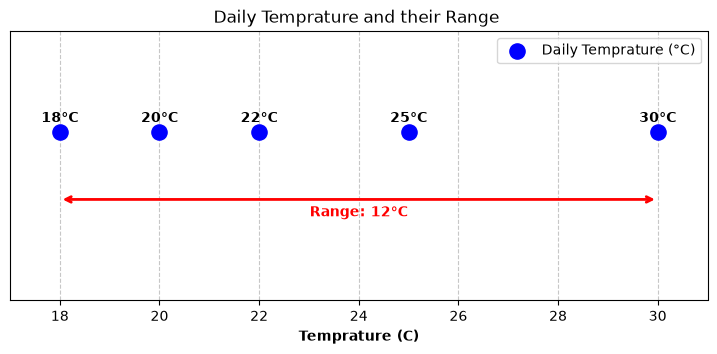

In [5]:
temperature = [18, 20,22, 25, 30]
min_value, max_value = min(temperature), max(temperature)

# plain python
range_python = max(temperature) - min(temperature)

range_numpy_minmax = np.max(temperature) - np.min(temperature)

range_np_ptp = np.ptp(temperature)

print(f"Plain python calculation:     {range_python}")
print(f"Numpy (np.min - np.max):     {range_numpy_minmax}")
print(f"Numpy (np.ptp):     {range_np_ptp}")

# generate visulization for the range
plt.figure(figsize=(9, 3.5))
plt.scatter(temperature, [1]*len(temperature), color='blue', s=120, zorder=2, label="Daily Temprature (°C)")

for i, temp in enumerate(temperature):
    plt.text(temp, 1.02, f"{temp}°C", ha='center', va='bottom', fontsize=10, fontweight='bold')
    
# plt.annotate("", xy=(max_value,0.8), xytext=(min_value,1), arrowprops=dict(arrowstyle="<->", color='red', lw=2))

plt.annotate(
    "",
    xy=(max_value, 0.8),
    xytext=(min_value, 0.8),
    arrowprops=dict(
        arrowstyle="<->",
        color="red",
        lw=2
    )
)

plt.text((min_value + max_value) / 2, 0.75, f"Range: {range_python}°C",
         ha='center', color='red', fontweight='bold')
    
plt.ylim(0.5, 1.3)
plt.xlim(min(temperature) - 1, max(temperature) + 1)
plt.yticks([])
plt.xlabel("Temprature (C)", fontweight='bold')
plt.title("Daily Temprature and their Range ")
plt.grid(True, linestyle='--', alpha=0.7, axis='x')
plt.legend()
plt.show()

2. Interquartile Range (IQR - Middle 50% Spread)

In [ ]:

def get_percentile_linear(data, percentile ):
    """Calculates percentile using linear interpolation (NumPy default equivalent)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    index = (percentile  / 100) * (n-1)
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

def get_percentile_weibull(data, percentile):
    """Calculates percentile using the Weibull method (similar to Excel's PERCENTILE.INC)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    rank = (percentile / 100) * (n + 1)
    index = rank - 1
    if index < 0:
        return sorted_data[0]
    elif index >= n-1:
        return sorted_data[-1]
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

scores = [10, 50, 60, 70, 80, 85, 100]

# Example usage
q1_linear = get_percentile_linear(scores, 25)
q3_linear = get_percentile_linear(scores, 75)
iqr_linear = q3_linear - q1_linear

# exclusive corresponds to the linear method in the statistics module
q1_stats_linear,_,q3_stats_linear = statistics.quantiles(scores, n=4, method='exclusive')
iqr_stats_linear = q3_stats_linear - q1_stats_linear
    

## Sample Variance (Average Squared Deviation)

In [ ]:
plants = [10, 20, 30]

mean_val = sum(plants) / len(plants)
var_python = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)

# standard Librabry(stats)
var_stats = statistics.variance(plants)

var_np = np.var(plants, ddof=1)

print(f"Plain Python calculations:   {var_python:.1f} cm2")
print(f"Statistic Variance:   {var_stats:.1f} cm2")
print(f"Variance at ddof = 1:  {var_np:.2f}")

Plain Python calculations:   100.0 cm2
Statistic Variance:   100.0 cm2
Variance at ddof - 1:  100.00


## Spread

In [ ]:
plants = [10, 20, 30]

mean_val = sum(plants) / len(plants)
var_val = sum((x - mean_val) ** 2 for x in plants) / (len(plants) -1)
std_python = math.sqrt(var_val)

std_stats = statistics.stdev(plants)

std_np = np.std(plants, ddof = 1)

print(f"Plain Python Calculations:   {std_python:.2f} cm2")
print(f"statistics.stdev():   {std_stats:.2f} cm2")
print(f"np.std(ddof=1):   {std_np:.2f} cm2")

In [ ]:
plants = [10,20,30]

mean_val = np.mean(plants)
std_val = np.std(plants, ddof = 1)

fig, ax = plt.subplots(figsize=(8,4.5))
x_indices = np.arange(1, len(plants) + 1)

bar = ax.bar(x_indices, plants, width=0.4, color='teal', alpha=0.6, label='plant Heights (cm)', edgecolor='black')

ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (x = {mean_val:0f} cm)')

for idx, h in zip(x_indices, plants):
    ax.annotate('', xy=(idx,h), xytext=(idx,mean_val),
                arrowprops=dict(arrowstyle='<->', color='purple'))

ax.axhspan(mean_val - std_val, mean_val + std_val, color='grid', alpha=0.15, label=f'+-1 std Dev Range (s = {std_val:.0f} cm)')

ax.set_xticks(x_indices)
ax.set_xticklabels(f'Plant {i}' for i in x_indices)
ax.set_ylabel('Height (cm)', fontweight=12)
ax.set_title('Devation from Mean')